In [9]:
# %%
from pathlib import Path
import re
import matplotlib.pyplot as plt


def extract_test_losses(file_path):
    file_path = Path(file_path)

    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        text = f.read()

    test_losses = [
        float(match.group(1)) * 1000
        for match in re.finditer(r"test loss:\s*([0-9.eE+-]+)", text)
    ]

    return test_losses


def clean_label(file_name):
    return Path(file_name).name.replace(".out", "").replace("_", " ")


def plot_test_losses(file_names):
    plt.figure(figsize=(9, 5))

    for file_name in file_names:
        test_losses = extract_test_losses(file_name)

        if len(test_losses) == 0:
            print(f"Warning: no test losses found in {file_name}")
            continue

        plt.plot(test_losses, label=clean_label(file_name))

    plt.xlabel("Epoch", fontsize=14)
    plt.ylabel("Test MSE loss [$10^{-3}$]", fontsize=14)
    plt.title("Test loss comparison", fontsize=14)

    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14)

    plt.legend(fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

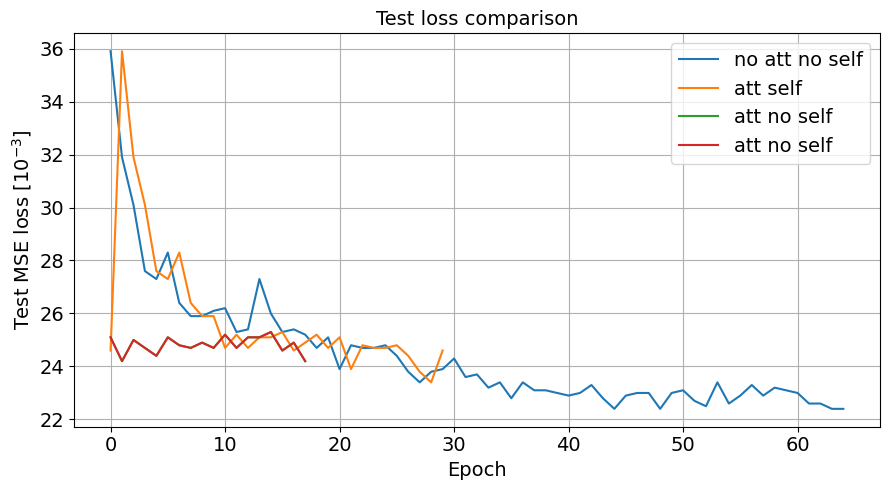

In [10]:
file_names = [
    "no_att_no_self.out",
   "att_self.out",
    "att_no_self.out",
    "att_no_self.out"
]

plot_test_losses(file_names)